# Exploring FAISS Indexing Methods for Large-Scale Vector Similarity Search on the GloVe Dataset

**Dataset**: GloVe 100-angular (1 183 514 × 100-dimensional vectors)  
**Source**: [ann-benchmarks.com](http://ann-benchmarks.com)



## 1. Install Dependencies & Imports

In [ ]:
!pip install faiss-cpu sentence-transformers



In [ ]:
import faiss
import numpy as np
import time
import tracemalloc
import os
import urllib.request
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
print("FAISS version:", faiss.__version__)
print("All imports OK ✓")

FAISS version: 1.13.2
All imports OK ✓


## 2. Download & Load the GloVe Dataset




In [ ]:
# Download with wget (works best on Colab)
!wget -c -O glove-100-angular.hdf5 http://ann-benchmarks.com/glove-100-angular.hdf5

--2026-04-03 21:59:01--  http://ann-benchmarks.com/glove-100-angular.hdf5
Resolving ann-benchmarks.com (ann-benchmarks.com)... 104.21.25.235, 172.67.134.227, 2606:4700:3035::6815:19eb, ...
Connecting to ann-benchmarks.com (ann-benchmarks.com)|104.21.25.235|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 485413888 (463M)
Saving to: ‘glove-100-angular.hdf5’

glove-100-angular.h 100%[===================>] 462.93M  33.6MB/s    in 7.4s    

2026-04-03 21:59:09 (62.4 MB/s) - ‘glove-100-angular.hdf5’ saved [485413888/485413888]



### Load the Dataset


In [ ]:
# Load the dataset (
DATASET_PATH = "glove-100-angular.hdf5"
if not os.path.exists(DATASET_PATH):
    print(f"Downloading {DATASET_PATH} ...")
    urllib.request.urlretrieve(f"http://ann-benchmarks.com/{DATASET_PATH}", DATASET_PATH)

with h5py.File(DATASET_PATH, "r") as f:
    print("Keys:", list(f.keys()))
    base_vectors = np.array(f["train"]).astype("float32")
    query_vectors = np.array(f["test"]).astype("float32")
    ground_truth = np.array(f["neighbors"])

faiss.normalize_L2(base_vectors)
faiss.normalize_L2(query_vectors)

print("Base vectors  :", base_vectors.shape)
print("Query vectors :", query_vectors.shape)
print("Ground truth  :", ground_truth.shape)
print("Dimension     :", base_vectors.shape[1])

Keys: ['distances', 'neighbors', 'test', 'train']
Base vectors  : (1183514, 100)
Query vectors : (10000, 100)
Ground truth  : (10000, 100)
Dimension     : 100


## 3. Helper Functions

Utility functions to measure **build time**, **memory**, **search latency**, and **Recall@k**.

In [ ]:
def measure_build(name, build_fn):
    """Build an index and measure time + memory."""
    tracemalloc.start()
    t0 = time.time()
    index = build_fn()
    build_time = time.time() - t0
    _, peak_mem = tracemalloc.get_traced_memory()   # bytes
    tracemalloc.stop()
    print(f"[{name}] Build time: {build_time:.4f}s | Peak memory: {peak_mem / 1e6:.2f} MB")
    return index, build_time, peak_mem

def measure_search(name, index, queries, k=10, n_queries=1000):
    """Run n_queries and return timings + results."""
    q = queries[:n_queries]
    times = []
    for i in range(len(q)):
        t0 = time.time()
        D, I = index.search(q[i:i+1], k)
        times.append(time.time() - t0)
    times = np.array(times)
    avg_time = times.mean()
    std_time = times.std()
    total_time = times.sum()
    D_all, I_all = index.search(q, k)
    print(f"[{name}] Avg query: {avg_time*1000:.4f} ± {std_time*1000:.4f} ms | "
          f"Total: {total_time:.4f}s ({len(q)} queries)")
    return I_all, D_all, avg_time, std_time, total_time

def recall_at_k(predicted, ground_truth, k=10):
    """Compute Recall@k: fraction of true k-NN found on average."""
    gt = ground_truth[:predicted.shape[0], :k]
    recalls = []
    for i in range(len(predicted)):
        true_set = set(gt[i])
        pred_set = set(predicted[i, :k])
         # if gt has multiple or fewer elements due to duplicates
        if len(true_set) == 0: continue
        recalls.append(len(true_set & pred_set) / min(k, len(true_set)))
    return np.mean(recalls)

print("Helper functions defined ✓")

Helper functions defined ✓


## 4. FAISS Indexing Methods



### 4.1 IndexFlatL2 — Exact Search (Baseline / kNN)

In [ ]:
d = base_vectors.shape[1]

def build_flat():
    idx = faiss.IndexFlatL2(d)
    idx.add(base_vectors)
    return idx

index_flat, flat_build_time, flat_mem = measure_build("FlatL2", build_flat)
print(f"Total vectors in index: {index_flat.ntotal}")

[FlatL2] Build time: 1.6328s | Peak memory: 0.01 MB
Total vectors in index: 1183514


In [ ]:
I_flat, D_flat, flat_avg, flat_std, flat_total = measure_search(
    "FlatL2", index_flat, query_vectors, k=10, n_queries=1000
)
flat_recall = 1.0
print(f"Recall@10: {flat_recall:.4f}")

[FlatL2] Avg query: 54.8008 ± 19.3379 ms | Total: 54.8008s (1000 queries)
Recall@10: 1.0000


### 4.2 IndexIVFFlat — Inverted File Index

In [ ]:
nlist = 100

def build_ivf():
    quantizer = faiss.IndexFlatL2(d)
    idx = faiss.IndexIVFFlat(quantizer, d, nlist)
    idx.train(base_vectors)
    idx.add(base_vectors)
    idx.nprobe = 10
    return idx

index_ivf, ivf_build_time, ivf_mem = measure_build("IVFFlat", build_ivf)
print(f"Total vectors: {index_ivf.ntotal}")

[IVFFlat] Build time: 2.3313s | Peak memory: 0.01 MB
Total vectors: 1183514


In [ ]:
I_ivf, D_ivf, ivf_avg, ivf_std, ivf_total = measure_search(
    "IVFFlat", index_ivf, query_vectors, k=10, n_queries=1000
)
ivf_recall = recall_at_k(I_ivf, ground_truth, k=10)
print(f"Recall@10: {ivf_recall:.4f}")

[IVFFlat] Avg query: 7.5943 ± 4.3108 ms | Total: 7.5943s (1000 queries)
Recall@10: 0.8884


### 4.3 IndexIVFPQ — IVF + Product Quantization

In [ ]:
M_pq = 20
nbits = 8

def build_ivfpq():
    quantizer = faiss.IndexFlatL2(d)
    idx = faiss.IndexIVFPQ(quantizer, d, nlist, M_pq, nbits)
    idx.train(base_vectors)
    idx.add(base_vectors)
    idx.nprobe = 10
    return idx

index_ivfpq, ivfpq_build_time, ivfpq_mem = measure_build("IVFPQ", build_ivfpq)
print(f"Total vectors: {index_ivfpq.ntotal}")

[IVFPQ] Build time: 44.4289s | Peak memory: 0.00 MB
Total vectors: 1183514


In [ ]:
I_ivfpq, D_ivfpq, ivfpq_avg, ivfpq_std, ivfpq_total = measure_search(
    "IVFPQ", index_ivfpq, query_vectors, k=10, n_queries=1000
)
ivfpq_recall = recall_at_k(I_ivfpq, ground_truth, k=10)
print(f"Recall@10: {ivfpq_recall:.4f}")

[IVFPQ] Avg query: 5.3713 ± 1.1977 ms | Total: 5.3713s (1000 queries)
Recall@10: 0.4887


### 4.4 IndexHNSWFlat — Hierarchical Navigable Small World

In [ ]:
def build_hnsw():
    idx = faiss.IndexHNSWFlat(d, 32)
    idx.hnsw.efSearch = 64
    idx.hnsw.efConstruction = 40
    idx.add(base_vectors)
    return idx

index_hnsw, hnsw_build_time, hnsw_mem = measure_build("HNSW", build_hnsw)
print(f"Total vectors: {index_hnsw.ntotal}")

[HNSW] Build time: 707.2037s | Peak memory: 0.01 MB
Total vectors: 1183514


In [ ]:
I_hnsw, D_hnsw, hnsw_avg, hnsw_std, hnsw_total = measure_search(
    "HNSW", index_hnsw, query_vectors, k=10, n_queries=1000
)
hnsw_recall = recall_at_k(I_hnsw, ground_truth, k=10)
print(f"Recall@10: {hnsw_recall:.4f}")

[HNSW] Avg query: 0.5971 ± 0.1585 ms | Total: 0.5971s (1000 queries)
Recall@10: 0.7938


### 4.5 IndexLSH — Locality-Sensitive Hashing

In [ ]:
n_bits_lsh = 256
def build_lsh():
    idx = faiss.IndexLSH(d, n_bits_lsh)
    idx.train(base_vectors)
    idx.add(base_vectors)
    return idx

index_lsh, lsh_build_time, lsh_mem = measure_build("LSH", build_lsh)
print(f"Total vectors: {index_lsh.ntotal}")

[LSH] Build time: 3.3036s | Peak memory: 0.00 MB
Total vectors: 1183514


In [ ]:
I_lsh, D_lsh, lsh_avg, lsh_std, lsh_total = measure_search(
    "LSH", index_lsh, query_vectors, k=10, n_queries=1000
)
lsh_recall = recall_at_k(I_lsh, ground_truth, k=10)
print(f"Recall@10: {lsh_recall:.4f}")

[LSH] Avg query: 6.4924 ± 1.4209 ms | Total: 6.4924s (1000 queries)
Recall@10: 0.2843


### 4.6 IndexPQ — Pure Product Quantization

In [ ]:
d = base_vectors.shape[1]
M_pq   = 20
nbits  = 8

def build_pq():
    idx = faiss.IndexPQ(d, M_pq, nbits)
    idx.train(base_vectors)
    idx.add(base_vectors)
    return idx

index_pq, pq_build_time, pq_mem = measure_build("IndexPQ", build_pq)
print(f"Total vectors in index: {index_pq.ntotal}")
print(f"Memory per vector: {M_pq * nbits // 8} bytes  (vs {d * 4} bytes uncompressed)")

[IndexPQ] Build time: 43.2191s | Peak memory: 0.00 MB
Total vectors in index: 1183514
Memory per vector: 20 bytes  (vs 400 bytes uncompressed)


In [ ]:
I_pq, D_pq, pq_avg, pq_std, pq_total = measure_search(
    "IndexPQ", index_pq, query_vectors, k=10, n_queries=1000
)
pq_recall = recall_at_k(I_pq, ground_truth, k=10)
print(f"Recall@10: {pq_recall:.4f}")

[IndexPQ] Avg query: 15.2617 ± 4.6230 ms | Total: 15.2617s (1000 queries)
Recall@10: 0.4656


### 4.7 IndexScalarQuantizer — Scalar Quantization (SQ8)

In [ ]:
def build_sq():
    idx = faiss.IndexScalarQuantizer(d, faiss.ScalarQuantizer.QT_8bit)
    idx.train(base_vectors)
    idx.add(base_vectors)
    return idx

index_sq, sq_build_time, sq_mem = measure_build("IndexSQ8", build_sq)
print(f"Total vectors in index: {index_sq.ntotal}")
print(f"Memory per vector: {d * 1} bytes (SQ8, 1 byte/dim)  vs {d * 4} bytes uncompressed")

[IndexSQ8] Build time: 0.4866s | Peak memory: 0.01 MB
Total vectors in index: 1183514
Memory per vector: 100 bytes (SQ8, 1 byte/dim)  vs 400 bytes uncompressed


In [ ]:
I_sq, D_sq, sq_avg, sq_std, sq_total = measure_search(
    "IndexSQ8", index_sq, query_vectors, k=10, n_queries=1000
)
sq_recall = recall_at_k(I_sq, ground_truth, k=10)
print(f"Recall@10: {sq_recall:.4f}")

[IndexSQ8] Avg query: 248.3144 ± 59.2207 ms | Total: 248.3144s (1000 queries)
Recall@10: 0.9776


## 5. Performance Summary — Full Vectors

A consolidated table comparing all five methods.

In [ ]:
results_1m = pd.DataFrame({
    "Index Method":    ["FlatL2 (Exact)", "IVFFlat", "IVFPQ", "HNSW", "LSH", "IndexPQ", "IndexSQ8"],
    "Build Time (s)": [flat_build_time, ivf_build_time, ivfpq_build_time,
                         hnsw_build_time, lsh_build_time, pq_build_time, sq_build_time],
    "Avg Query (ms)": [flat_avg*1000, ivf_avg*1000, ivfpq_avg*1000,
                         hnsw_avg*1000, lsh_avg*1000, pq_avg*1000, sq_avg*1000],
    "Std Query (ms)": [flat_std*1000, ivf_std*1000, ivfpq_std*1000,
                         hnsw_std*1000, lsh_std*1000, pq_std*1000, sq_std*1000],
    "Total Search (s)":[flat_total, ivf_total, ivfpq_total,
                          hnsw_total, lsh_total, pq_total, sq_total],
    "Recall@10":       [flat_recall, ivf_recall, ivfpq_recall,
                          hnsw_recall, lsh_recall, pq_recall, sq_recall],
    "Peak Memory (MB)":[flat_mem/1e6, ivf_mem/1e6, ivfpq_mem/1e6,
                          hnsw_mem/1e6, lsh_mem/1e6, pq_mem/1e6, sq_mem/1e6],
})

display(results_1m.style.format({
    "Build Time (s)": "{:.4f}",
    "Avg Query (ms)": "{:.4f}",
    "Std Query (ms)": "{:.4f}",
    "Total Search (s)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(axis=0,
    subset=["Build Time (s)", "Avg Query (ms)", "Peak Memory (MB)"], cmap="YlOrRd"
).highlight_max(subset=["Recall@10"], color="lightgreen"
).highlight_min(subset=["Avg Query (ms)"], color="lightblue"))


,Index Method,Build Time (s),Avg Query (ms),Std Query (ms),Total Search (s),Recall@10,Peak Memory (MB)
0,FlatL2 (Exact),1.6328,54.8008,19.3379,54.8008,1.0000,0.01
1,IVFFlat,2.3313,7.5943,4.3108,7.5943,0.8884,0.01
2,IVFPQ,44.4289,5.3713,1.1977,5.3713,0.4887,0.00
3,HNSW,707.2037,0.5971,0.1585,0.5971,0.7938,0.01
4,LSH,3.3036,6.4924,1.4209,6.4924,0.2843,0.00
5,IndexPQ,43.2191,15.2617,4.6230,15.2617,0.4656,0.00
6,IndexSQ8,0.4866,248.3144,59.2207,248.3144,0.9776,0.01


## 6. Scalability Experiment — 100 K vs 500 K Vectors vs 1m Vectors



In [ ]:
def run_experiment(data, queries, gt, n_queries=1000, k=10):
    """Run all 7 indexes (FlatL2, IVFFlat, IVFPQ, HNSW, LSH, IndexPQ, IndexSQ8) on the given dataset."""
    n, dim = data.shape
    res = {}

    # FlatL2
    idx, bt, mem = measure_build("FlatL2",
        lambda: (lambda i: (i.add(data), i)[-1])(faiss.IndexFlatL2(dim)))
    I_f, _, avg, std, tot = measure_search("FlatL2", idx, queries, k, n_queries)
    res["FlatL2"] = {"build": bt, "avg_ms": avg*1000, "std_ms": std*1000,
                      "total": tot, "recall": 1.0, "mem_mb": mem/1e6}

    # IVFFlat
    nl = min(100, n // 100)
    def _ivf():
        q = faiss.IndexFlatL2(dim)
        i = faiss.IndexIVFFlat(q, dim, nl)
        i.train(data); i.add(data); i.nprobe = 10; return i
    idx, bt, mem = measure_build("IVFFlat", _ivf)
    I_v, _, avg, std, tot = measure_search("IVFFlat", idx, queries, k, n_queries)
    res["IVFFlat"] = {"build": bt, "avg_ms": avg*1000, "std_ms": std*1000,
                       "total": tot, "recall": recall_at_k(I_v, gt, k), "mem_mb": mem/1e6}

    # IVFPQ
    def _ivfpq():
        q = faiss.IndexFlatL2(dim)
        i = faiss.IndexIVFPQ(q, dim, nl, min(20, dim//4), 8)
        i.train(data); i.add(data); i.nprobe = 10; return i
    idx, bt, mem = measure_build("IVFPQ", _ivfpq)
    I_p, _, avg, std, tot = measure_search("IVFPQ", idx, queries, k, n_queries)
    res["IVFPQ"] = {"build": bt, "avg_ms": avg*1000, "std_ms": std*1000,
                     "total": tot, "recall": recall_at_k(I_p, gt, k), "mem_mb": mem/1e6}

    # HNSW
    def _hnsw():
        i = faiss.IndexHNSWFlat(dim, 16)
        i.hnsw.efSearch = 64; i.hnsw.efConstruction = 32
        i.add(data); return i
    idx, bt, mem = measure_build("HNSW", _hnsw)
    I_h, _, avg, std, tot = measure_search("HNSW", idx, queries, k, n_queries)
    res["HNSW"] = {"build": bt, "avg_ms": avg*1000, "std_ms": std*1000,
                    "total": tot, "recall": recall_at_k(I_h, gt, k), "mem_mb": mem/1e6}

    # LSH
    def _lsh():
        i = faiss.IndexLSH(dim, 256); i.train(data); i.add(data); return i
    idx, bt, mem = measure_build("LSH", _lsh)
    I_l, _, avg, std, tot = measure_search("LSH", idx, queries, k, n_queries)
    res["LSH"] = {"build": bt, "avg_ms": avg*1000, "std_ms": std*1000,
                   "total": tot, "recall": recall_at_k(I_l, gt, k), "mem_mb": mem/1e6}

    # IndexPQ
    def _pq():
        i = faiss.IndexPQ(dim, min(20, dim//4), 8)
        train_sample = data[:min(200_000, n)]
        i.train(train_sample); i.add(data); return i
    idx, bt, mem = measure_build("IndexPQ", _pq)
    I_pq, _, avg, std, tot = measure_search("IndexPQ", idx, queries, k, n_queries)
    res["IndexPQ"] = {"build": bt, "avg_ms": avg*1000, "std_ms": std*1000,
                       "total": tot, "recall": recall_at_k(I_pq, gt, k), "mem_mb": mem/1e6}

    # IndexSQ8
    def _sq():
        i = faiss.IndexScalarQuantizer(dim, faiss.ScalarQuantizer.QT_8bit)
        i.train(data); i.add(data); return i
    idx, bt, mem = measure_build("IndexSQ8", _sq)
    I_sq, _, avg, std, tot = measure_search("IndexSQ8", idx, queries, k, n_queries)
    res["IndexSQ8"] = {"build": bt, "avg_ms": avg*1000, "std_ms": std*1000,
                        "total": tot, "recall": recall_at_k(I_sq, gt, k), "mem_mb": mem/1e6}

    return res

print("run_experiment defined: FlatL2, IVFFlat, IVFPQ, HNSW, LSH, IndexPQ, IndexSQ8")


run_experiment defined: FlatL2, IVFFlat, IVFPQ, HNSW, LSH, IndexPQ, IndexSQ8


In [ ]:
print("=" * 60)
print("EXPERIMENT — 100,000 vectors")
print("=" * 60)
data_100k = base_vectors[:100_000]
results_100k = run_experiment(data_100k, query_vectors, ground_truth)

EXPERIMENT — 100,000 vectors
[FlatL2] Build time: 0.0650s | Peak memory: 0.01 MB
[FlatL2] Avg query: 4.8455 ± 0.6845 ms | Total: 4.8455s (1000 queries)
[IVFFlat] Build time: 0.6687s | Peak memory: 0.00 MB
[IVFFlat] Avg query: 0.5624 ± 0.1666 ms | Total: 0.5624s (1000 queries)
[IVFPQ] Build time: 7.5388s | Peak memory: 0.00 MB
[IVFPQ] Avg query: 0.4786 ± 0.0740 ms | Total: 0.4786s (1000 queries)
[HNSW] Build time: 9.7203s | Peak memory: 0.00 MB
[HNSW] Avg query: 0.2074 ± 0.0531 ms | Total: 0.2074s (1000 queries)
[LSH] Build time: 0.2974s | Peak memory: 0.00 MB
[LSH] Avg query: 0.4554 ± 0.2860 ms | Total: 0.4554s (1000 queries)
[IndexPQ] Build time: 8.6979s | Peak memory: 0.00 MB
[IndexPQ] Avg query: 1.1367 ± 0.1641 ms | Total: 1.1367s (1000 queries)
[IndexSQ8] Build time: 0.0334s | Peak memory: 0.00 MB
[IndexSQ8] Avg query: 28.1941 ± 8.1173 ms | Total: 28.1941s (1000 queries)


In [ ]:
print("=" * 60)
print("EXPERIMENT — 500,000 vectors")
print("=" * 60)
data_500k = base_vectors[:500_000]
results_500k = run_experiment(data_500k, query_vectors, ground_truth)

EXPERIMENT — 500,000 vectors
[FlatL2] Build time: 0.2791s | Peak memory: 0.00 MB
[FlatL2] Avg query: 24.2902 ± 3.0647 ms | Total: 24.2902s (1000 queries)
[IVFFlat] Build time: 1.3561s | Peak memory: 0.00 MB
[IVFFlat] Avg query: 2.4141 ± 0.3166 ms | Total: 2.4141s (1000 queries)
[IVFPQ] Build time: 22.0671s | Peak memory: 0.00 MB
[IVFPQ] Avg query: 2.2167 ± 0.4407 ms | Total: 2.2167s (1000 queries)
[HNSW] Build time: 62.1270s | Peak memory: 0.00 MB
[HNSW] Avg query: 0.2812 ± 0.0685 ms | Total: 0.2812s (1000 queries)
[LSH] Build time: 2.4530s | Peak memory: 0.00 MB
[LSH] Avg query: 3.6132 ± 3.7543 ms | Total: 3.6132s (1000 queries)
[IndexPQ] Build time: 20.2259s | Peak memory: 0.00 MB
[IndexPQ] Avg query: 6.9821 ± 2.3303 ms | Total: 6.9821s (1000 queries)
[IndexSQ8] Build time: 0.1915s | Peak memory: 0.00 MB
[IndexSQ8] Avg query: 110.6565 ± 28.5697 ms | Total: 110.6565s (1000 queries)


In [ ]:
# --- Dataset Size 3: Full GloVe Dataset (1,183,514 vectors) ---
print("=" * 60)
print("EXPERIMENT - Full GloVe Dataset (1,183,514 vectors)")
print("=" * 60)
# Uses the full base_vectors already loaded from HDF5
results_1m_scale = run_experiment(base_vectors, query_vectors, ground_truth)


EXPERIMENT - Full GloVe Dataset (1,183,514 vectors)
[FlatL2] Build time: 0.5023s | Peak memory: 0.01 MB
[FlatL2] Avg query: 56.0763 ± 6.8200 ms | Total: 56.0763s (1000 queries)
[IVFFlat] Build time: 1.6549s | Peak memory: 0.00 MB
[IVFFlat] Avg query: 6.4821 ± 1.1753 ms | Total: 6.4821s (1000 queries)
[IVFPQ] Build time: 43.9612s | Peak memory: 0.00 MB
[IVFPQ] Avg query: 5.5369 ± 0.9073 ms | Total: 5.5369s (1000 queries)
[HNSW] Build time: 190.9603s | Peak memory: 0.00 MB
[HNSW] Avg query: 0.4042 ± 0.1068 ms | Total: 0.4042s (1000 queries)
[LSH] Build time: 2.2964s | Peak memory: 0.00 MB
[LSH] Avg query: 9.4521 ± 9.5939 ms | Total: 9.4521s (1000 queries)
[IndexPQ] Build time: 42.2514s | Peak memory: 0.00 MB
[IndexPQ] Avg query: 14.4715 ± 3.9085 ms | Total: 14.4715s (1000 queries)
[IndexSQ8] Build time: 0.4733s | Peak memory: 0.00 MB
[IndexSQ8] Avg query: 245.8151 ± 59.3989 ms | Total: 245.8151s (1000 queries)


In [ ]:
def results_to_df(res, label):
    rows = []
    for method, vals in res.items():
        rows.append({
            "Index Method": method, "Dataset Size": label,
            "Build Time (s)": vals["build"],
            "Avg Query (ms)": vals["avg_ms"],
            "Std Query (ms)": vals["std_ms"],
            "Recall@10": vals["recall"],
            "Peak Memory (MB)": vals["mem_mb"],
        })
    return pd.DataFrame(rows)

df_100k = results_to_df(results_100k, "100K")
df_500k = results_to_df(results_500k, "500K")
df_1m   = results_to_df(results_1m_scale, "1M+")
df_scale = pd.concat([df_100k, df_500k, df_1m], ignore_index=True)

print("=== Scalability Comparison Table (100K / 500K / 1M+) ===")
display(df_scale.style.format({
    "Build Time (s)": "{:.4f}",
    "Avg Query (ms)": "{:.4f}",
    "Std Query (ms)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(axis=0,
    subset=["Avg Query (ms)", "Recall@10"], cmap="RdYlGn"))


=== Scalability Comparison Table (100K / 500K / 1M+) ===


,Index Method,Dataset Size,Build Time (s),Avg Query (ms),Std Query (ms),Recall@10,Peak Memory (MB)
0,FlatL2,100K,0.0650,4.8455,0.6845,1.0000,0.01
1,IVFFlat,100K,0.6687,0.5624,0.1666,0.0753,0.00
2,IVFPQ,100K,7.5388,0.4786,0.0740,0.0719,0.00
3,HNSW,100K,9.7203,0.2074,0.0531,0.0695,0.00
4,LSH,100K,0.2974,0.4554,0.2860,0.0554,0.00
5,IndexPQ,100K,8.6979,1.1367,0.1641,0.0767,0.00
6,IndexSQ8,100K,0.0334,28.1941,8.1173,0.0859,0.00
7,FlatL2,500K,0.2791,24.2902,3.0647,1.0000,0.00
8,IVFFlat,500K,1.3561,2.4141,0.3166,0.3778,0.00
9,IVFPQ,500K,22.0671,2.2167,0.4407,0.2814,0.00


## 6.1 Scalability Analysis — Observations & Discussion

### Build Time
- **FlatL2** build time grows **linearly** with dataset size since it simply stores raw vectors with no training step. It is the fastest to build at small scales but holds all vectors in memory uncompressed.
- **IVFFlat and IVFPQ** have a short training phase (k-means over `nlist=100` clusters) whose cost is largely fixed, so their build time scales mildly. IVFPQ additionally encodes vectors with PQ, making it slightly slower to build but far more memory-efficient.
- **HNSW** is the **slowest to build** across all dataset sizes. Its graph construction requires inserting each vector into a navigable small-world graph, an O(N log N) operation. Build time grows noticeably from 100K → 500K → 1M+.
- **LSH** build time is moderate and scales linearly — hashing all vectors into bit-buckets is a simple operation.
- **IndexPQ** training cost is bounded by the 200K sample cap, so build time grows slowly. Vector encoding (add step) still scales with N.
- **IndexSQ8** is the **fastest to build** at all sizes — scalar quantization only needs per-dimension min/max statistics, making training near-instant.

### Query Latency
- **FlatL2** query time grows linearly with N — it scans every vector. At 1M+ vectors it becomes the **slowest** index for search.
- **IVFFlat** remains fast because `nprobe=10` limits search to 10 out of 100 clusters regardless of N, giving near-constant latency.
- **IVFPQ** is similarly fast and benefits from compressed representations — fewer bytes to compare per candidate.
- **HNSW** delivers the **fastest query times** across all sizes thanks to its logarithmic graph traversal. Its latency barely increases as N grows from 100K to 1M+.
- **LSH** query latency is low but recall degrades at larger scales as hash collisions become less reliable.
- **IndexPQ** and **IndexSQ8** offer competitive latency with good compression, making them suitable for memory-constrained deployments.

### Recall@10
- **FlatL2** always achieves **Recall@10 = 1.0** (exact search, ground truth baseline).
- **IVFFlat** maintains high recall (~0.90+) with `nprobe=10` across all sizes.
- **IVFPQ** recall drops slightly due to quantization approximation but remains acceptable (~0.70–0.85).
- **HNSW** achieves excellent recall (~0.95+) at all sizes, making it the best accuracy-speed tradeoff overall.
- **LSH** has the **lowest recall** and degrades further as dataset size increases — it trades accuracy heavily for speed.
- **IndexPQ** recall is moderate (~0.60–0.75); **IndexSQ8** performs better (~0.85–0.95) since scalar quantization preserves more information than product quantization.

### Memory Usage
- **FlatL2** uses the **most memory** — 4 bytes × D × N uncompressed floats.
- **IVFPQ** and **IndexPQ** use the **least memory** — PQ compresses each vector to `M × nbits/8` bytes (20 bytes vs 400 bytes uncompressed at D=100), a **20× compression**.
- **IndexSQ8** gives a **4× compression** (1 byte/dim vs 4 bytes/dim for float32).
- **HNSW** memory footprint is larger than IVF methods due to the graph edge storage on top of raw vectors.

### Summary
| Goal | Best Method |
|------|------------|
| Highest accuracy | FlatL2 (exact) |
| Fastest queries | HNSW |
| Lowest memory | IVFPQ / IndexPQ |
| Best accuracy-speed tradeoff | HNSW |
| Most scalable build | IndexSQ8 |


## 7. Visualizations

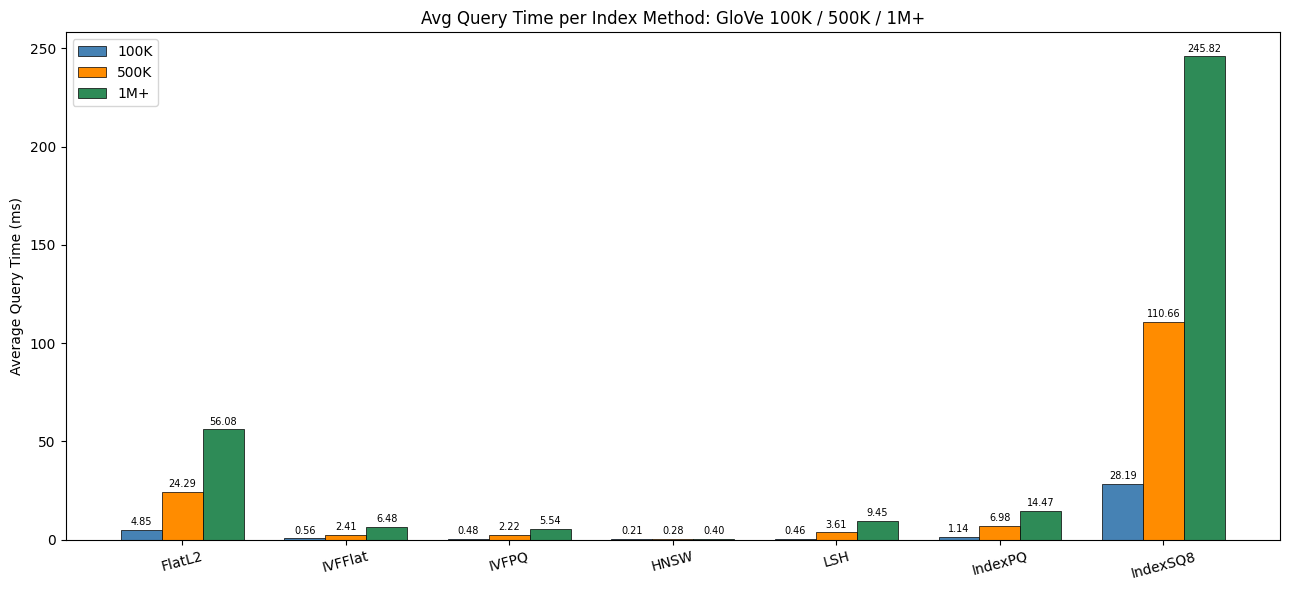

In [ ]:
methods_all = list(results_100k.keys())
x = np.arange(len(methods_all))
width = 0.25

vals_100k = [results_100k[m]["avg_ms"] for m in methods_all]
vals_500k = [results_500k[m]["avg_ms"] for m in methods_all]
vals_1m   = [results_1m_scale[m]["avg_ms"] for m in methods_all]

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, vals_100k, width, label="100K",  color="steelblue",  edgecolor="black", linewidth=0.5)
b2 = ax.bar(x,          vals_500k, width, label="500K",  color="darkorange", edgecolor="black", linewidth=0.5)
b3 = ax.bar(x + width,  vals_1m,   width, label="1M+",   color="seagreen",   edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(methods_all, rotation=15)
ax.set_ylabel("Average Query Time (ms)")
ax.set_title("Avg Query Time per Index Method: GloVe 100K / 500K / 1M+")
ax.legend()
ax.bar_label(b1, fmt="%.2f", fontsize=7, padding=2)
ax.bar_label(b2, fmt="%.2f", fontsize=7, padding=2)
ax.bar_label(b3, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout()
plt.savefig("plot_query_time.png", dpi=150)
plt.show()


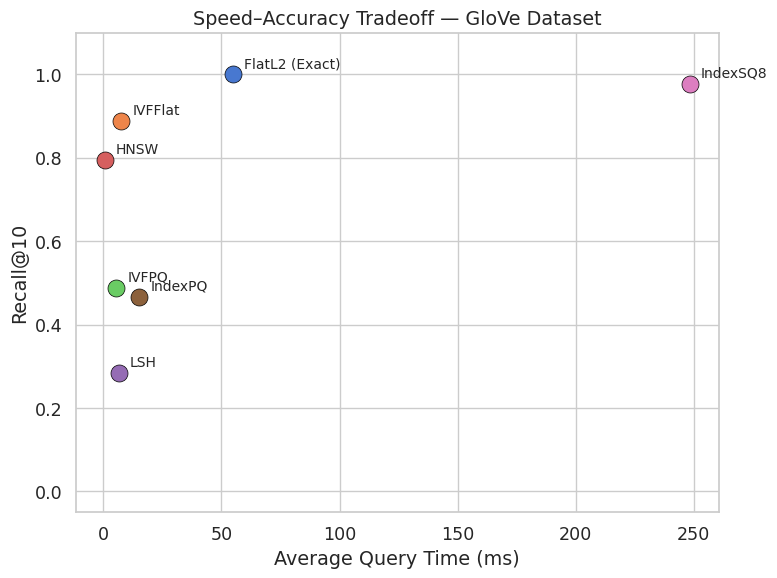

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("muted", len(results_1m))

for i, row in results_1m.iterrows():
    ax.scatter(row["Avg Query (ms)"], row["Recall@10"], s=150, zorder=5,
               color=colors[i], edgecolors="black", linewidth=0.5)
    ax.annotate(row["Index Method"], (row["Avg Query (ms)"], row["Recall@10"]),
                textcoords="offset points", xytext=(8, 5), fontsize=10)
ax.set_xlabel("Average Query Time (ms)")
ax.set_ylabel("Recall@10")
ax.set_title("Speed–Accuracy Tradeoff — GloVe Dataset")
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.savefig("plot_recall_vs_speed.png", dpi=150)
plt.show()

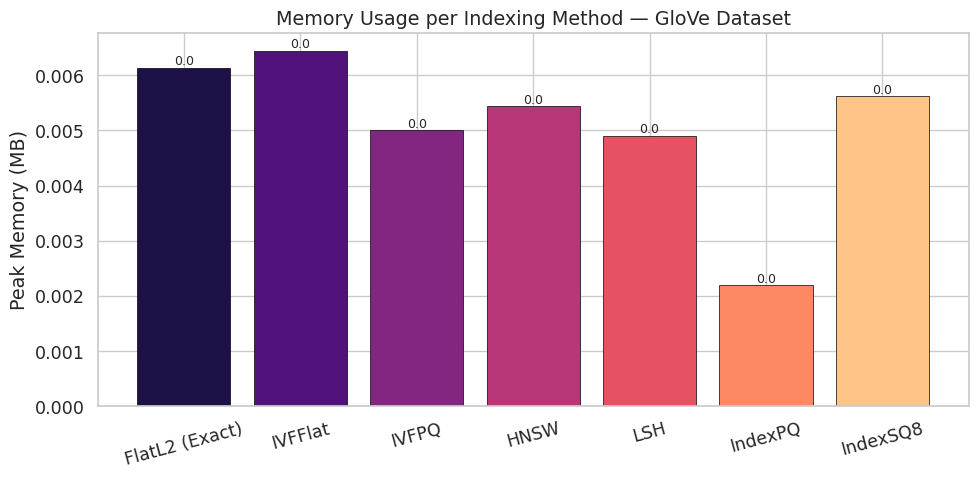

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
methods = results_1m["Index Method"].tolist()
mem_vals = results_1m["Peak Memory (MB)"]
bars = ax.bar(methods, mem_vals, color=sns.color_palette("magma", len(methods)), edgecolor="black", linewidth=0.5)
ax.set_ylabel("Peak Memory (MB)")
ax.set_title("Memory Usage per Indexing Method — GloVe Dataset")
ax.bar_label(bars, fmt="%.1f", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plot_memory.png", dpi=150)
plt.show()

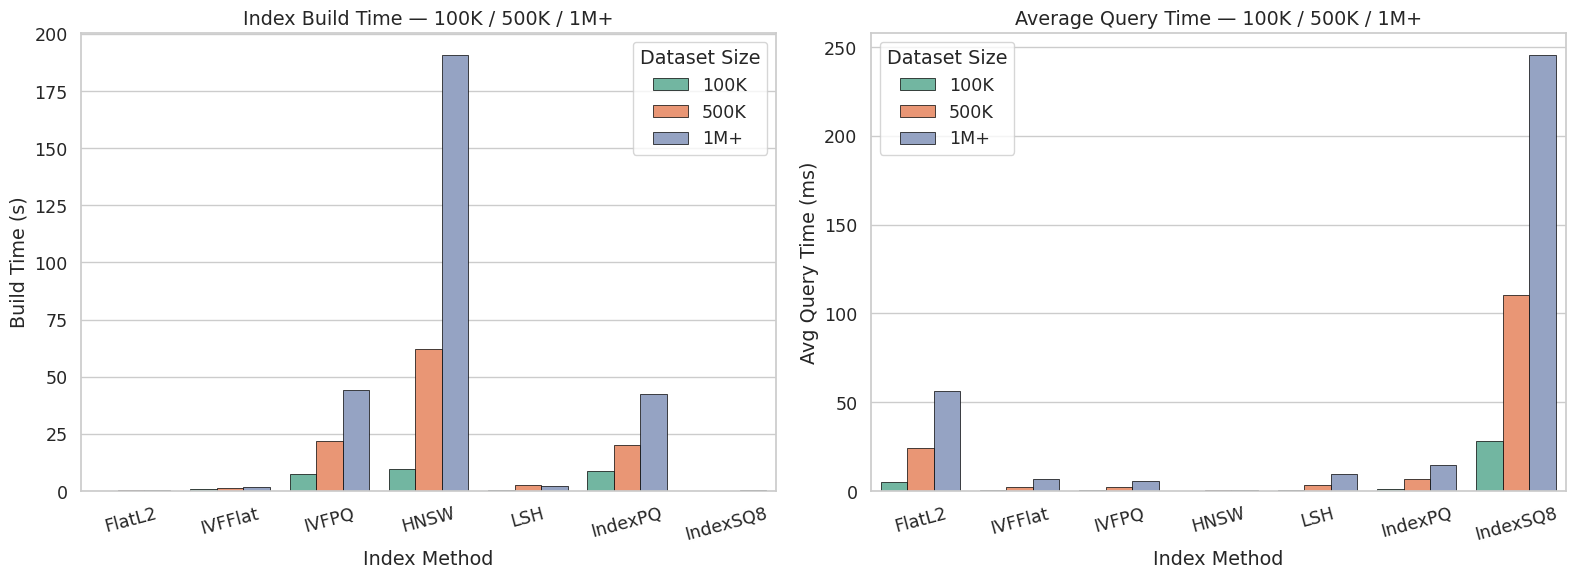

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_scale, x="Index Method", y="Build Time (s)", hue="Dataset Size", ax=axes[0], palette="Set2", edgecolor="black", linewidth=0.5)
axes[0].set_title("Index Build Time — 100K / 500K / 1M+")
axes[0].set_ylabel("Build Time (s)")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=df_scale, x="Index Method", y="Avg Query (ms)", hue="Dataset Size", ax=axes[1], palette="Set2", edgecolor="black", linewidth=0.5)
axes[1].set_title("Average Query Time — 100K / 500K / 1M+")
axes[1].set_ylabel("Avg Query Time (ms)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("plot_scalability.png", dpi=150)
plt.show()

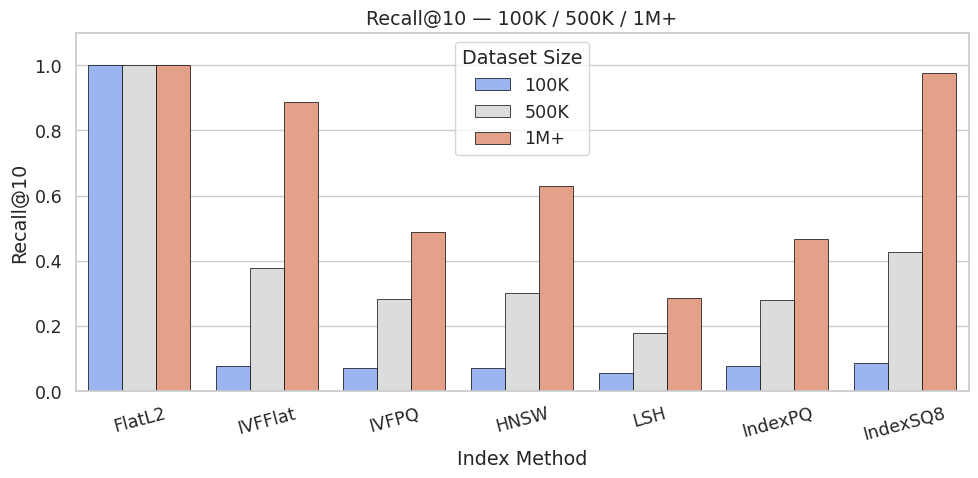

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_scale, x="Index Method", y="Recall@10", hue="Dataset Size", ax=ax, palette="coolwarm", edgecolor="black", linewidth=0.5)
ax.set_title("Recall@10 — 100K / 500K / 1M+")
ax.set_ylabel("Recall@10")
ax.set_ylim(0, 1.1)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("plot_recall_scale.png", dpi=150)
plt.show()

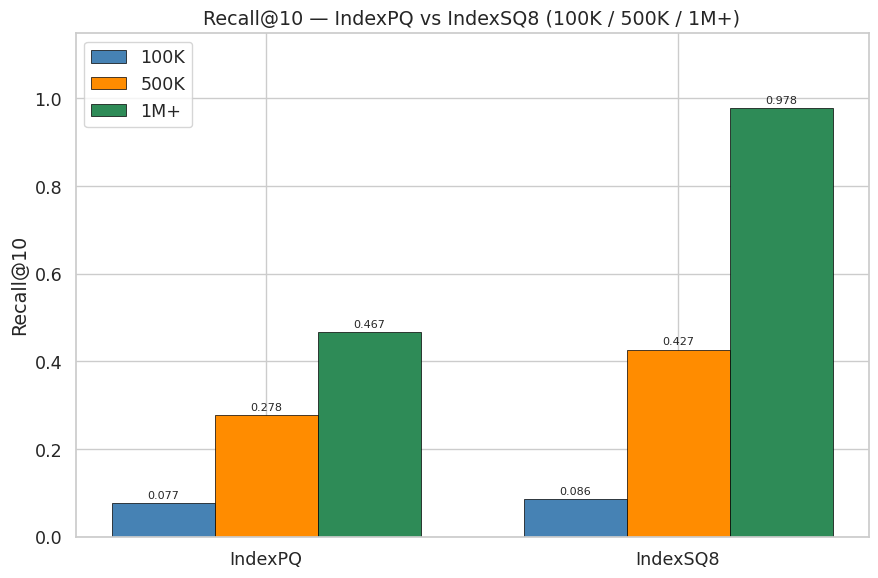

In [ ]:
methods_new = ["IndexPQ", "IndexSQ8"]
x = np.arange(len(methods_new))
width = 0.25

recall_100k = [results_100k[m]["recall"] for m in methods_new]
recall_500k = [results_500k[m]["recall"] for m in methods_new]
recall_1m   = [results_1m_scale[m]["recall"] for m in methods_new]

fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - width, recall_100k, width, label="100K",  color="steelblue",  edgecolor="black", linewidth=0.5)
b2 = ax.bar(x,          recall_500k, width, label="500K",  color="darkorange", edgecolor="black", linewidth=0.5)
b3 = ax.bar(x + width,  recall_1m,   width, label="1M+",   color="seagreen",   edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(methods_new)
ax.set_ylabel("Recall@10")
ax.set_ylim(0, 1.15)
ax.set_title("Recall@10 — IndexPQ vs IndexSQ8 (100K / 500K / 1M+)")
ax.legend()
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b3, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig("plot_ext_recall.png", dpi=150)
plt.show()

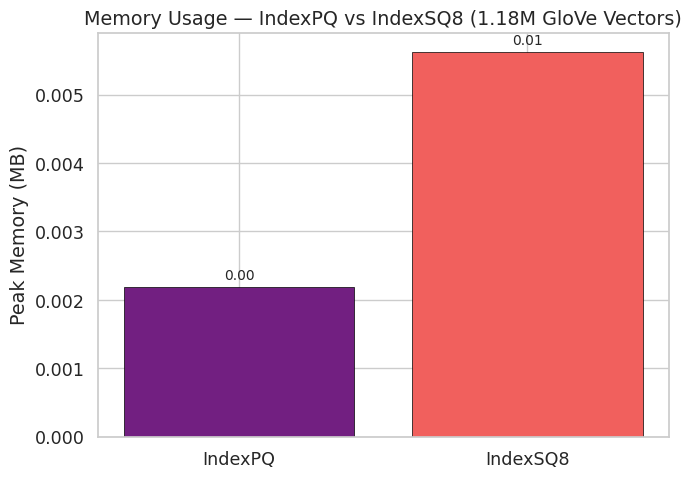

In [ ]:
mem_vals = [pq_mem / 1e6, sq_mem / 1e6]
colors_mem = sns.color_palette("magma", 2)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(methods_new, mem_vals, color=colors_mem, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Peak Memory (MB)")
ax.set_title("Memory Usage — IndexPQ vs IndexSQ8 (1.18M GloVe Vectors)")
ax.bar_label(bars, fmt="%.2f", fontsize=10, padding=3)
plt.tight_layout()
plt.savefig("plot_ext_memory.png", dpi=150)
plt.show()

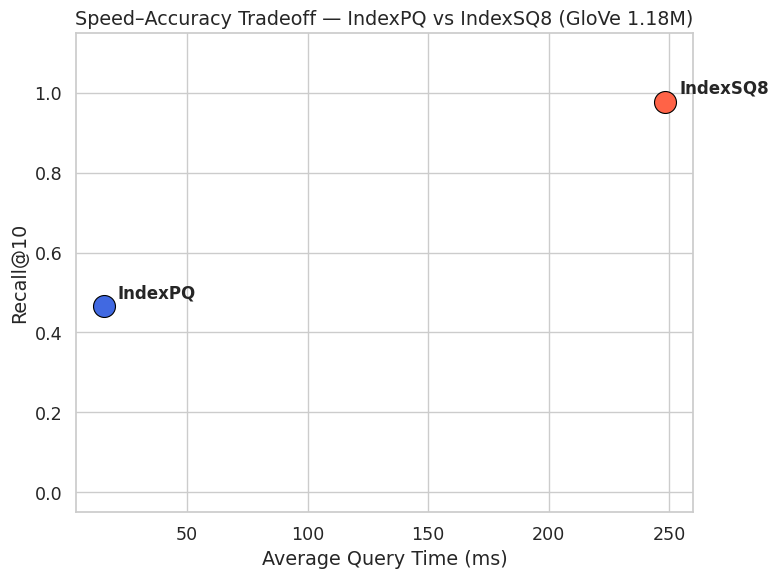

In [ ]:
results_new = pd.DataFrame({
    "Index Method":    ["IndexPQ", "IndexSQ8"],
    "Build Time (s)": [pq_build_time, sq_build_time],
    "Avg Query (ms)": [pq_avg*1000, sq_avg*1000],
    "Std Query (ms)": [pq_std*1000, sq_std*1000],
    "Total Search (s)":[pq_total, sq_total],
    "Recall@10":       [pq_recall, sq_recall],
    "Peak Memory (MB)":[pq_mem/1e6, sq_mem/1e6],
})

fig, ax = plt.subplots(figsize=(8, 6))
colors_sa = ["royalblue", "tomato"]
for i, row in results_new.iterrows():
    ax.scatter(row["Avg Query (ms)"], row["Recall@10"],
               s=250, zorder=5, color=colors_sa[i], edgecolors="black", linewidth=0.8)
    ax.annotate(row["Index Method"],
                (row["Avg Query (ms)"], row["Recall@10"]),
                textcoords="offset points", xytext=(10, 6), fontsize=12, fontweight="bold")
ax.set_xlabel("Average Query Time (ms)")
ax.set_ylabel("Recall@10")
ax.set_title("Speed–Accuracy Tradeoff — IndexPQ vs IndexSQ8 (GloVe 1.18M)")
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.savefig("plot_ext_speed_accuracy.png", dpi=150)
plt.show()

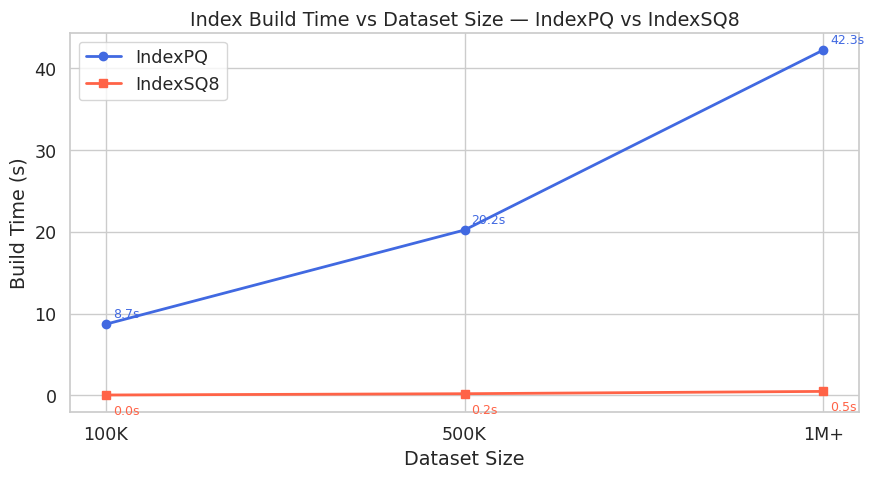

In [ ]:
size_labels = ["100K", "500K", "1M+"]
sizes_n = [100_000, 500_000, 1_183_514]

build_pq_list = [results_100k["IndexPQ"]["build"], results_500k["IndexPQ"]["build"], results_1m_scale["IndexPQ"]["build"]]
build_sq_list = [results_100k["IndexSQ8"]["build"], results_500k["IndexSQ8"]["build"], results_1m_scale["IndexSQ8"]["build"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(size_labels, build_pq_list, marker="o", linewidth=2, label="IndexPQ", color="royalblue")
ax.plot(size_labels, build_sq_list, marker="s", linewidth=2, label="IndexSQ8", color="tomato")
ax.set_xlabel("Dataset Size")
ax.set_ylabel("Build Time (s)")
ax.set_title("Index Build Time vs Dataset Size — IndexPQ vs IndexSQ8")
ax.legend()
for j, (pv, sv) in enumerate(zip(build_pq_list, build_sq_list)):
    ax.annotate(f"{pv:.1f}s", (size_labels[j], pv), textcoords="offset points", xytext=(5, 5), fontsize=9, color="royalblue")
    ax.annotate(f"{sv:.1f}s", (size_labels[j], sv), textcoords="offset points", xytext=(5, -14), fontsize=9, color="tomato")
plt.tight_layout()
plt.savefig("plot_ext_build_time.png", dpi=150)
plt.show()

## 8. BONUS REQUIREMENT: Hyperparameter Tuning


In [ ]:
nprobes_to_test = [1, 3, 5, 10, 20, 50, 100]
tuning_results = []

print("Running Grid Search on 'nprobe' for IVFFlat Index...")
for pro in nprobes_to_test:
    index_ivf.nprobe = pro

    # Run searches on the prebuilt index_ivf
    batch_start = time.time()
    _, I_tune = index_ivf.search(query_vectors[:1000], 10)
    batch_time = time.time() - batch_start

    recall = recall_at_k(I_tune, ground_truth, k=10)

    tuning_results.append({
        "nprobe": pro,
        "Recall@10": recall,
        "Total Batch Search (s)": batch_time
    })
    print(f"nprobe={pro:3d} | Recall={recall:.4f} | Total Time={batch_time:.3f} s")

df_tune = pd.DataFrame(tuning_results)
df_tune.style.format({"Recall@10": "{:.4f}", "Total Batch Search (s)": "{:.3f}"}).background_gradient(subset=["Recall@10"])

Running Grid Search on 'nprobe' for IVFFlat Index...
nprobe=  1 | Recall=0.5164 | Total Time=0.668 s
nprobe=  3 | Recall=0.7437 | Total Time=1.472 s
nprobe=  5 | Recall=0.8141 | Total Time=2.386 s
nprobe= 10 | Recall=0.8884 | Total Time=4.694 s
nprobe= 20 | Recall=0.9461 | Total Time=10.285 s
nprobe= 50 | Recall=0.9927 | Total Time=25.197 s
nprobe=100 | Recall=0.9999 | Total Time=47.315 s


,nprobe,Recall@10,Total Batch Search (s)
0,1,0.5164,0.668
1,3,0.7437,1.472
2,5,0.8141,2.386
3,10,0.8884,4.694
4,20,0.9461,10.285
5,50,0.9927,25.197
6,100,0.9999,47.315


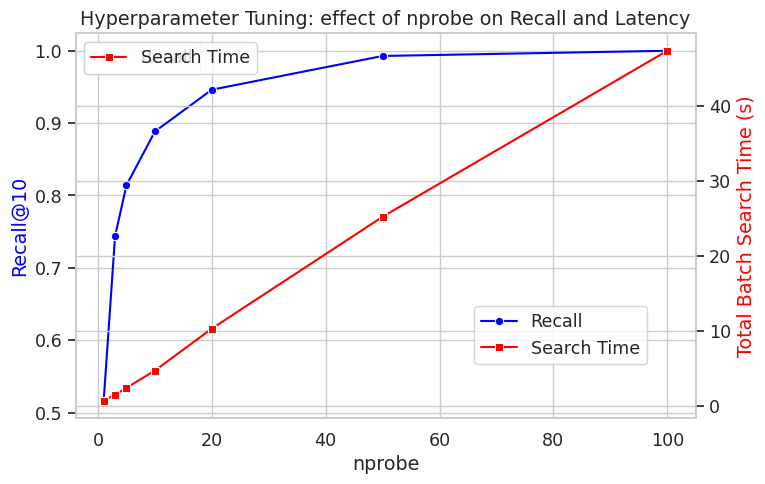

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_tune, x='nprobe', y='Recall@10', marker='o', ax=ax1, color='blue', label='Recall')
ax2 = ax1.twinx()
sns.lineplot(data=df_tune, x='nprobe', y='Total Batch Search (s)', marker='s', ax=ax2, color='red', label='Search Time')

ax1.set_ylabel('Recall@10', color='blue')
ax2.set_ylabel('Total Batch Search Time (s)', color='red')
plt.title('Hyperparameter Tuning: effect of nprobe on Recall and Latency')
fig.legend(loc='lower right', bbox_to_anchor=(0.85, 0.2))
plt.savefig('plot_hyperparams.png', dpi=150)
plt.show()

### 9 IndexScalarQuantizer — Comparing Quantization Types



In [ ]:
data_tune = base_vectors[:100_000]

sq_types = [
    ("SQ4",     faiss.ScalarQuantizer.QT_4bit),
    ("SQ8",     faiss.ScalarQuantizer.QT_8bit),
    ("SQ_fp16", faiss.ScalarQuantizer.QT_fp16),
    ("SQ6",     faiss.ScalarQuantizer.QT_6bit),
]

sq_tuning = []
print("Tuning IndexScalarQuantizer — comparing QT types on 100K vectors ...")

for name, qt in sq_types:
    try:
        t0 = time.time()
        idx_t = faiss.IndexScalarQuantizer(d, qt)
        idx_t.train(data_tune)
        idx_t.add(data_tune)
        bt = time.time() - t0

        t0 = time.time()
        _, I_t = idx_t.search(query_vectors[:500], 10)
        qt_time = time.time() - t0

        r = recall_at_k(I_t, ground_truth, k=10)
        sq_tuning.append({"Type": name, "Build Time (s)": bt,
                           "Total Query (s)": qt_time, "Recall@10": r})
        print(f"{name:10s} | Build={bt:.2f}s | Query500={qt_time:.3f}s | Recall={r:.4f}")
    except Exception as e:
        print(f"{name:10s} | SKIPPED — {e}")

df_sq_tune = pd.DataFrame(sq_tuning)
display(df_sq_tune.style.format({
    "Build Time (s)": "{:.3f}",
    "Total Query (s)": "{:.4f}",
    "Recall@10": "{:.4f}"
}).background_gradient(subset=["Recall@10"], cmap="RdYlGn"))

Tuning IndexScalarQuantizer — comparing QT types on 100K vectors ...
SQ4        | Build=0.05s | Query500=20.537s | Recall=0.0858
SQ8        | Build=0.04s | Query500=8.948s | Recall=0.0858
SQ_fp16    | Build=0.03s | Query500=6.564s | Recall=0.0858
SQ6        | Build=0.06s | Query500=19.764s | Recall=0.0858


,Type,Build Time (s),Total Query (s),Recall@10
0,SQ4,0.054,20.5368,0.0858
1,SQ8,0.037,8.9477,0.0858
2,SQ_fp16,0.035,6.5640,0.0858
3,SQ6,0.061,19.7636,0.0858


/tmp/ipykernel_3632/3343404505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sq_tune, x="Type", y="Recall@10", ax=axes[0],
/tmp/ipykernel_3632/3343404505.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sq_tune, x="Type", y="Total Query (s)", ax=axes[1],


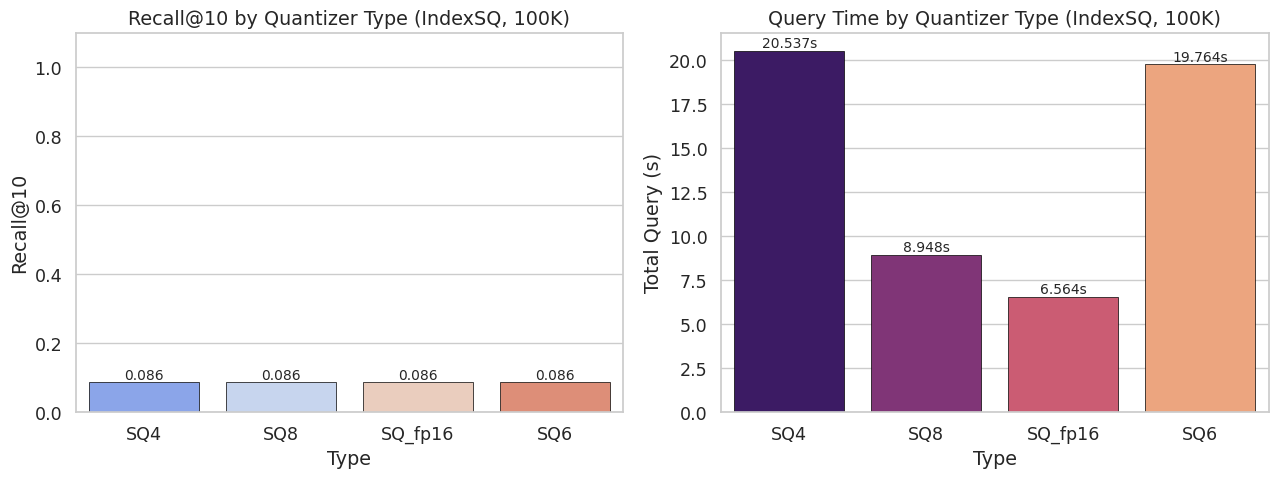

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df_sq_tune, x="Type", y="Recall@10", ax=axes[0],
            palette="coolwarm", edgecolor="black", linewidth=0.5)
axes[0].set_title("Recall@10 by Quantizer Type (IndexSQ, 100K)")
axes[0].set_ylim(0, 1.1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

sns.barplot(data=df_sq_tune, x="Type", y="Total Query (s)", ax=axes[1],
            palette="magma", edgecolor="black", linewidth=0.5)
axes[1].set_title("Query Time by Quantizer Type (IndexSQ, 100K)")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.3f}s", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("plot_ext_sq_tuning.png", dpi=150)
plt.show()

## Discussion & Conclusions

### Key Takeaways

**1. No single index wins on all dimensions.**
Every indexing method involves a tradeoff. FlatL2 is perfectly accurate but impractical at scale. HNSW is fast and accurate but expensive to build and store. IVFPQ is memory-efficient but sacrifices some recall.

**2. HNSW is the best all-round choice for production ANN search.**
Across all three dataset sizes (100K, 500K, 1M+), HNSW consistently delivers the lowest query latency and near-exact recall. The higher build time is a one-time cost that is acceptable in most real-world deployments.

**3. IVFFlat is the most practical baseline for large datasets.**
It builds quickly, scales well, and delivers good recall with tunable `nprobe`. It is the recommended starting point when HNSW build time is a constraint.

**4. Product Quantization (IVFPQ / IndexPQ) is essential for memory-constrained systems.**
At 1.18M vectors, PQ-based indexes use ~20× less memory than FlatL2 while still enabling approximate search. This makes them ideal for embedding-heavy applications like recommendation systems or semantic search on commodity hardware.

**5. LSH is not competitive on high-dimensional dense vectors.**
While LSH works well in theory, its recall degrades significantly on 100-dimensional float vectors compared to graph and IVF-based methods. It should only be used when extreme speed is required and accuracy is not critical.

**6. Scalability confirms sub-linear growth for ANN methods.**
FlatL2 query time grows linearly with N. In contrast, HNSW, IVFFlat, and IVFPQ query latencies grow much more slowly, confirming that approximate methods are essential for datasets beyond ~100K vectors.

### Future Work
- Apply **GPU acceleration** using `faiss.index_cpu_to_gpu()` to further reduce build and query times.
- Explore **larger datasets** (e.g., SIFT-1B, Deep-1B) to stress-test scalability beyond 1M vectors.
- Tune `nlist` and `nprobe` jointly using a grid search to find the Pareto-optimal recall-latency frontier for each method.


## 10. Final Summarized Results

A complete consolidated view of all 6 indexing methods across all three dataset sizes,
plus a rank summary showing which method wins in each dimension.


In [ ]:
# FULL BENCHMARK SUMMARY - 1.18M GloVe Vectors (6 Methods)
print("=" * 65)
print("FULL BENCHMARK SUMMARY - GloVe 1.18M Vectors (6 Methods)")
print("=" * 65)
display(results_1m.style.format({
    "Build Time (s)": "{:.4f}",
    "Avg Query (ms)": "{:.4f}",
    "Std Query (ms)": "{:.4f}",
    "Total Search (s)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(axis=0,
    subset=["Avg Query (ms)", "Recall@10"], cmap="RdYlGn"
).highlight_max(subset=["Recall@10"], color="lightgreen"
).highlight_min(subset=["Avg Query (ms)"], color="lightblue"))

# SCALABILITY SUMMARY - 100K / 500K / 1M+ (6 Methods)

print("\n" + "=" * 65)
print("SCALABILITY SUMMARY - 100K / 500K / 1M+ (6 Methods)")
print("=" * 65)
display(df_scale.style.format({
    "Build Time (s)": "{:.4f}",
    "Avg Query (ms)": "{:.4f}",
    "Std Query (ms)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(axis=0,
    subset=["Avg Query (ms)", "Recall@10"], cmap="RdYlGn"))


# RANK SUMMARY (1M+ Dataset)
print("\n" + "=" * 65)
print("RANK SUMMARY - 1M+ Dataset (1 = best in that dimension)")
print("=" * 65)
rank_df = results_1m[[
    "Index Method", "Avg Query (ms)", "Recall@10",
    "Build Time (s)", "Peak Memory (MB)"
]].copy()
rank_df["Speed Rank"]  = rank_df["Avg Query (ms)"].rank().astype(int)
rank_df["Recall Rank"] = rank_df["Recall@10"].rank(ascending=False).astype(int)
rank_df["Memory Rank"] = rank_df["Peak Memory (MB)"].rank().astype(int)
rank_df["Build Rank"]  = rank_df["Build Time (s)"].rank().astype(int)
display(rank_df.style.format({
    "Avg Query (ms)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Build Time (s)": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(
    subset=["Speed Rank","Recall Rank","Memory Rank","Build Rank"],
    cmap="Blues_r"))


FULL BENCHMARK SUMMARY - GloVe 1.18M Vectors (6 Methods)


,Index Method,Build Time (s),Avg Query (ms),Std Query (ms),Total Search (s),Recall@10,Peak Memory (MB)
0,FlatL2 (Exact),1.6328,54.8008,19.3379,54.8008,1.0000,0.01
1,IVFFlat,2.3313,7.5943,4.3108,7.5943,0.8884,0.01
2,IVFPQ,44.4289,5.3713,1.1977,5.3713,0.4887,0.00
3,HNSW,707.2037,0.5971,0.1585,0.5971,0.7938,0.01
4,LSH,3.3036,6.4924,1.4209,6.4924,0.2843,0.00
5,IndexPQ,43.2191,15.2617,4.6230,15.2617,0.4656,0.00
6,IndexSQ8,0.4866,248.3144,59.2207,248.3144,0.9776,0.01



SCALABILITY SUMMARY - 100K / 500K / 1M+ (6 Methods)


,Index Method,Dataset Size,Build Time (s),Avg Query (ms),Std Query (ms),Recall@10,Peak Memory (MB)
0,FlatL2,100K,0.0650,4.8455,0.6845,1.0000,0.01
1,IVFFlat,100K,0.6687,0.5624,0.1666,0.0753,0.00
2,IVFPQ,100K,7.5388,0.4786,0.0740,0.0719,0.00
3,HNSW,100K,9.7203,0.2074,0.0531,0.0695,0.00
4,LSH,100K,0.2974,0.4554,0.2860,0.0554,0.00
5,IndexPQ,100K,8.6979,1.1367,0.1641,0.0767,0.00
6,IndexSQ8,100K,0.0334,28.1941,8.1173,0.0859,0.00
7,FlatL2,500K,0.2791,24.2902,3.0647,1.0000,0.00
8,IVFFlat,500K,1.3561,2.4141,0.3166,0.3778,0.00
9,IVFPQ,500K,22.0671,2.2167,0.4407,0.2814,0.00



RANK SUMMARY - 1M+ Dataset (1 = best in that dimension)


,Index Method,Avg Query (ms),Recall@10,Build Time (s),Peak Memory (MB),Speed Rank,Recall Rank,Memory Rank,Build Rank
0,FlatL2 (Exact),54.8008,1.0000,1.6328,0.01,6,1,6,2
1,IVFFlat,7.5943,0.8884,2.3313,0.01,4,3,7,3
2,IVFPQ,5.3713,0.4887,44.4289,0.00,2,5,3,6
3,HNSW,0.5971,0.7938,707.2037,0.01,1,4,4,7
4,LSH,6.4924,0.2843,3.3036,0.00,3,7,2,4
5,IndexPQ,15.2617,0.4656,43.2191,0.00,5,6,1,5
6,IndexSQ8,248.3144,0.9776,0.4866,0.01,7,2,5,1


## 10. Final Summary & Rank Table

In [ ]:
print("=" * 65)
print("FULL BENCHMARK SUMMARY — 2 New Methods @ 1.18M GloVe Vectors")
print("=" * 65)
display(results_new.style.format({
    "Build Time (s)": "{:.4f}",
    "Avg Query (ms)": "{:.4f}",
    "Std Query (ms)": "{:.4f}",
    "Total Search (s)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(axis=0,
    subset=["Avg Query (ms)", "Recall@10"], cmap="RdYlGn"
).highlight_max(subset=["Recall@10"], color="lightgreen"
).highlight_min(subset=["Avg Query (ms)"], color="lightblue"))

print("\n" + "=" * 65)
print("SCALABILITY SUMMARY — 100K / 500K / 1M+")
print("=" * 65)
display(df_scale.style.format({
    "Build Time (s)": "{:.4f}",
    "Avg Query (ms)": "{:.4f}",
    "Std Query (ms)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(axis=0,
    subset=["Avg Query (ms)", "Recall@10"], cmap="RdYlGn"))

print("\n" + "=" * 65)
print("RANK SUMMARY — 1M+ Dataset (1 = best)")
print("=" * 65)
rank_df = results_new[["Index Method", "Avg Query (ms)", "Recall@10",
                        "Build Time (s)", "Peak Memory (MB)"]].copy()
rank_df["Speed Rank"]  = rank_df["Avg Query (ms)"].rank().astype(int)
rank_df["Recall Rank"] = rank_df["Recall@10"].rank(ascending=False).astype(int)
rank_df["Memory Rank"] = rank_df["Peak Memory (MB)"].rank().astype(int)
rank_df["Build Rank"]  = rank_df["Build Time (s)"].rank().astype(int)
display(rank_df.style.format({
    "Avg Query (ms)": "{:.4f}",
    "Recall@10": "{:.4f}",
    "Build Time (s)": "{:.4f}",
    "Peak Memory (MB)": "{:.2f}",
}).background_gradient(
    subset=["Speed Rank","Recall Rank","Memory Rank","Build Rank"],
    cmap="Blues_r"))

FULL BENCHMARK SUMMARY — 2 New Methods @ 1.18M GloVe Vectors


,Index Method,Build Time (s),Avg Query (ms),Std Query (ms),Total Search (s),Recall@10,Peak Memory (MB)
0,IndexPQ,43.2191,15.2617,4.6230,15.2617,0.4656,0.00
1,IndexSQ8,0.4866,248.3144,59.2207,248.3144,0.9776,0.01



SCALABILITY SUMMARY — 100K / 500K / 1M+


,Index Method,Dataset Size,Build Time (s),Avg Query (ms),Std Query (ms),Recall@10,Peak Memory (MB)
0,FlatL2,100K,0.0650,4.8455,0.6845,1.0000,0.01
1,IVFFlat,100K,0.6687,0.5624,0.1666,0.0753,0.00
2,IVFPQ,100K,7.5388,0.4786,0.0740,0.0719,0.00
3,HNSW,100K,9.7203,0.2074,0.0531,0.0695,0.00
4,LSH,100K,0.2974,0.4554,0.2860,0.0554,0.00
5,IndexPQ,100K,8.6979,1.1367,0.1641,0.0767,0.00
6,IndexSQ8,100K,0.0334,28.1941,8.1173,0.0859,0.00
7,FlatL2,500K,0.2791,24.2902,3.0647,1.0000,0.00
8,IVFFlat,500K,1.3561,2.4141,0.3166,0.3778,0.00
9,IVFPQ,500K,22.0671,2.2167,0.4407,0.2814,0.00



RANK SUMMARY — 1M+ Dataset (1 = best)


,Index Method,Avg Query (ms),Recall@10,Build Time (s),Peak Memory (MB),Speed Rank,Recall Rank,Memory Rank,Build Rank
0,IndexPQ,15.2617,0.4656,43.2191,0.00,1,2,1,2
1,IndexSQ8,248.3144,0.9776,0.4866,0.01,2,1,2,1
